In [171]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional
import pandas as pd

In [172]:
df = pd.read_csv('./data.csv')
point = list(zip(list(df['x']),list(df['y'])))
region_list = list(df['label'])
region = torch.zeros(len(region_list),max(region_list)+1)
region.scatter_(
    dim = 1,
    index = torch.tensor(region_list).unsqueeze(1),
    value = 1.0
)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        ...,
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

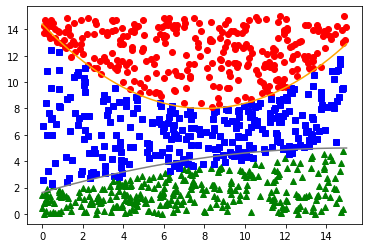

In [173]:
for i in range(len(point)):
  if(region[i][0]==1):
    plt.plot(point[i][0],point[i][1],'ro')
  elif(region[i][1]==1):
    plt.plot(point[i][0],point[i][1],'bs')
  else:
    plt.plot(point[i][0],point[i][1],'g^')

x = np.linspace(0,15,1000)
y1 = 0.1*(x-8)**2+8
y2 = -0.015*(x-15)**2+5
plt.plot(x,y1,'orange')
plt.plot(x,y2,'gray')
plt.show()

In [174]:
def classify(x,y):
  region = [0,0,0]
  if(y>(0.1*(x-8)**2+8)):
    region[0] = 1
  elif (y<(0.1*(x-8)**2+8) and y>(-0.015*(x-15)**2+5)):
    region[1] = 1
  else:
    region[2] = 1
  return region

In [175]:
# date preprocess
inputs = torch.FloatTensor(point)
labels = torch.FloatTensor(region)

inputs[:5],labels[:5]

(tensor([[ 7.7368, 14.5052],
         [10.3166,  7.5875],
         [ 0.9838,  1.4846],
         [ 9.8746, 12.5638],
         [ 7.3008,  5.9231]]), tensor([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.],
         [1., 0., 0.],
         [0., 1., 0.]]))

In [176]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"# Enable CUDA if possible
print(f"device is {device}")

class MyModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MyModel, self).__init__()
        hidden_dim = 10
        self.linear_1 = nn.Linear(2, hidden_dim)
        self.linear_2 = nn.Linear(hidden_dim, output_dim)
        #self.LogSoftmax = nn.LogSoftmax(dim=0)
        #self.relu = nn.ReLU()

    def forward(self, inputs):
      outputs = self.linear_1(inputs).requires_grad_()      
      outputs = self.linear_2(outputs).requires_grad_()
      #outputs = self.relu(outputs).requires_grad_()
      #outputs = self.LogSoftmax(outputs).requires_grad_()
      return outputs
        
# 4. Create an instance of the model and send it to target device
model = MyModel(2,3).to(device)

print(model.parameters)# Type of parameter object

device is cpu
<bound method Module.parameters of MyModel(
  (linear_1): Linear(in_features=2, out_features=10, bias=True)
  (linear_2): Linear(in_features=10, out_features=3, bias=True)
)>


In [177]:
# Create a loss function
criterion = nn.CrossEntropyLoss()  

# Create an optimizer
learning_rate = 8e-2
optimizer = torch.optim.SGD(params=model.parameters(),lr=learning_rate)

In [178]:
torch.manual_seed(42)

num_epochs = 1000 # Train for longer
softmax = nn.Softmax(dim=0)
# Put data to target device
inputs, labels = inputs.to(device), labels.to(device)

for epoch in range(num_epochs):
    predicts = model(inputs).squeeze()
    loss = criterion(predicts,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print out what's happening every 10 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}")


Epoch: 0 | Loss: 3.76133
Epoch: 100 | Loss: 0.42976
Epoch: 200 | Loss: 0.35528
Epoch: 300 | Loss: 0.31453
Epoch: 400 | Loss: 0.28674
Epoch: 500 | Loss: 0.26581
Epoch: 600 | Loss: 0.24916
Epoch: 700 | Loss: 0.23548
Epoch: 800 | Loss: 0.22400
Epoch: 900 | Loss: 0.21421


In [179]:
#Validation
val_pts = [[1,0],[1,1],[0,1]]
val_pts = torch.FloatTensor(val_pts)
for i in range(3):
  x = val_pts[i][0]
  y = val_pts[i][1]
  predict_region = softmax(model(val_pts[i])).tolist()
  print(f"point {x},{y}, predict = {predict_region}, ans = {classify(x,y)}")

val_pts = torch.rand(10,2)
for i in range(5):
  x = val_pts[i][0]
  y = val_pts[i][1]
  predict_region = softmax(model(val_pts[i])).tolist()
  print(f"point {x},{y}, predict = {predict_region}, ans = {classify(x,y)}")

point 1.0,0.0, predict = [3.798747272298897e-08, 0.00010812768596224487, 0.9998918771743774], ans = [0, 0, 1]
point 1.0,1.0, predict = [7.528333753725747e-06, 0.007855916395783424, 0.9921365976333618], ans = [0, 0, 1]
point 0.0,1.0, predict = [1.704580063233152e-05, 0.017078572884202003, 0.9829043745994568], ans = [0, 0, 1]
point 0.8822692632675171,0.9150039553642273, predict = [5.299666099745082e-06, 0.0059938798658549786, 0.9940008521080017], ans = [0, 0, 1]
point 0.38286375999450684,0.9593056440353394, predict = [1.0078179911943153e-05, 0.010683499276638031, 0.9893063902854919], ans = [0, 0, 1]
point 0.3904482126235962,0.600895345211029, predict = [1.5129589883144945e-06, 0.002298725303262472, 0.9976997971534729], ans = [0, 0, 1]
point 0.2565724849700928,0.7936413288116455, predict = [4.674648607760901e-06, 0.005821645725518465, 0.9941737055778503], ans = [0, 0, 1]
point 0.9407714605331421,0.13318592309951782, predict = [8.076972335402388e-08, 0.00020065775606781244, 0.9997993111610